<a href="https://colab.research.google.com/github/Varshini151205/DL/blob/main/DL_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Autoencoder**

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 0.3065 - val_loss: 0.2654
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.2637 - val_loss: 0.2602
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.2546 - val_loss: 0.2464
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.2373 - val_loss: 0.2266
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.2187 - val_loss: 0.2100
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.2037 - val_loss: 0.1961
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1912 - val_loss: 0.1847
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1811 - val_loss: 0.1758
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1731 - val_loss: 0.1686
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1665 - val_loss: 0.1624
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1608 - val_lo

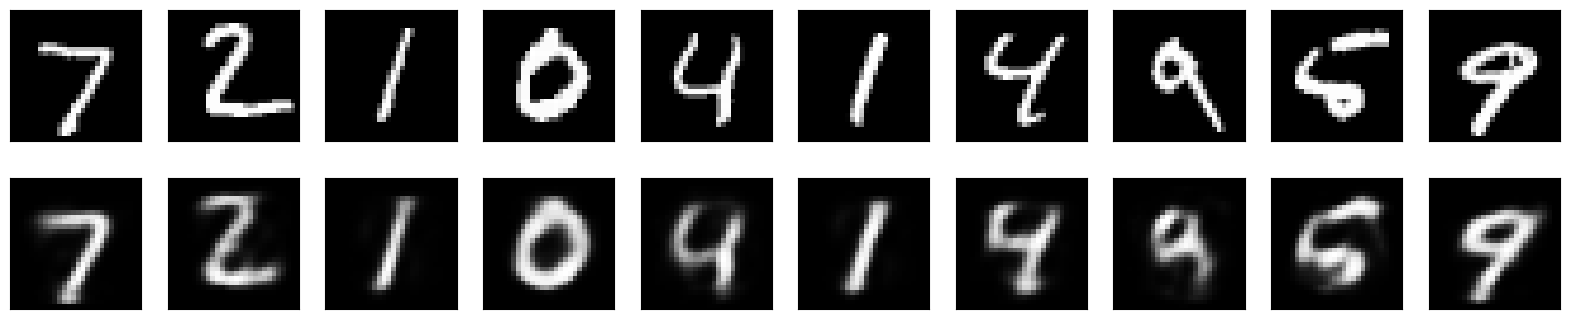

In [1]:
import numpy as np
from tensorflow.keras.layers import Input,Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard
(x_train,_),(x_test,_)=mnist.load_data()
x_train=x_train.astype('float32')/255.
x_test=x_test.astype('float32')/255.
x_train=x_train.reshape((len(x_train),np.prod(x_train.shape[1:])))
x_test=x_test.reshape((len(x_test),np.prod(x_test.shape[1:])))
input_dim=784
encoding_dim=64

input_layer=Input(shape=(input_dim,))
encoded=Dense(encoding_dim,activation='sigmoid')(input_layer)
decoded=Dense(input_dim,activation='sigmoid')(encoded)

autoencoder=Model(input_layer,decoded)
autoencoder.compile(optimizer='adam',loss='binary_crossentropy')
autoencoder.fit(x_train,x_train,epochs=20,batch_size=256,shuffle=True,validation_data=(x_test,x_test))
decoded_imgs=autoencoder.predict(x_test)
n=10
plt.figure(figsize=(20,4))
for i in range(n):
 ax=plt.subplot(2,n,i+1)
 plt.imshow(x_test[i].reshape(28,28))
 plt.gray()
 ax.get_xaxis().set_visible(False)
 ax.get_yaxis().set_visible(False)
 ax=plt.subplot(2,n,i+1+n)
 plt.imshow(decoded_imgs[i].reshape(28,28))
 plt.gray()
 ax.get_xaxis().set_visible(False)
 ax.get_yaxis().set_visible(False)
plt.show()

**Implement Undercomplete AE and Overcomplete AE and write your observations. (Write your observations on how much low and high dimensions the image can be compressed)**

In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Load MNIST
data = datasets.MNIST(root='./data', train=True, download=True,
                      transform=transforms.ToTensor())
loader = DataLoader(data, batch_size=128, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# undercomplete
class UnderAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 64),   # 🔻 compressed
        )
        self.decoder = nn.Sequential(
            nn.Linear(64, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x.view(-1,1,28,28)

# overcomplete
class OverAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 1024),  # 🔺 expanded
        )
        self.decoder = nn.Sequential(
            nn.Linear(1024, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x.view(-1,1,28,28)

# train
def train(model):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    for epoch in range(3):   # small training
        for img, _ in loader:
            img = img.to(device)

            out = model(img)
            loss = loss_fn(out, img)

            opt.zero_grad()
            loss.backward()
            opt.step()

        print("Epoch:", epoch+1, "Loss:", loss.item())

# Run models
print("Undercomplete AE")
train(UnderAE())

print("\nOvercomplete AE")
train(OverAE())

100%|██████████| 9.91M/9.91M [00:00<00:00, 123MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 38.2MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 97.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.30MB/s]


Undercomplete AE
Epoch: 1 Loss: 0.02213507518172264
Epoch: 2 Loss: 0.012829294428229332
Epoch: 3 Loss: 0.00788009911775589

Overcomplete AE
Epoch: 1 Loss: 0.00458555668592453
Epoch: 2 Loss: 0.002074169460684061
Epoch: 3 Loss: 0.0013638415839523077


**Implement Regularization in AE**

In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Load MNIST
data = datasets.MNIST(root='./data', train=True, download=True,
                      transform=transforms.ToTensor())
loader = DataLoader(data, batch_size=128, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Simple Autoencoder
class AE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 64),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(64, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x.view(-1,1,28,28)

model = AE().to(device)

# Optimizer with L2 Regularization (weight_decay)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

loss_fn = nn.MSELoss()

# Training
for epoch in range(3):
    for img, _ in loader:
        img = img.to(device)

        output = model(img)
        loss = loss_fn(output, img)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.0253
Epoch 2, Loss: 0.0154
Epoch 3, Loss: 0.0110


**Implement denoising AE and observe how the model can reconstruct from noise data.**

In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Load MNIST
data = datasets.MNIST(root='./data', train=True, download=True,
                      transform=transforms.ToTensor())
loader = DataLoader(data, batch_size=128, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#Model
class DenoisingAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 64),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(64, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x.view(-1,1,28,28)

model = DenoisingAE().to(device)

# Add Noise
def add_noise(x, noise_factor=0.3):
    noise = torch.randn_like(x) * noise_factor
    return torch.clamp(x + noise, 0., 1.)

# Training
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

for epoch in range(3):
    for img, _ in loader:
        img = img.to(device)

        noisy_img = add_noise(img)     # input = noisy
        output = model(noisy_img)      # output = clean

        loss = loss_fn(output, img)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.0327
Epoch 2, Loss: 0.0213
Epoch 3, Loss: 0.0182


**Demonstrate PCA with AE on a dataset.**

In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.decomposition import PCA

# Load MNIST
data = datasets.MNIST(root='./data', train=True, download=True,
                      transform=transforms.ToTensor())

loader = DataLoader(data, batch_size=1000, shuffle=False)

# Take one batch for demo
images, _ = next(iter(loader))
X = images.view(-1, 784).numpy()
pca = PCA(n_components=32)   # compress to 32 dims
X_pca = pca.fit_transform(X)
X_recon_pca = pca.inverse_transform(X_pca)

print("PCA done")
class AE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 32)   # same size as PCA
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

model = AE()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

X_tensor = torch.tensor(X, dtype=torch.float32)

# Train (short)
for epoch in range(5):
    output = model(X_tensor)
    loss = loss_fn(output, X_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print("Epoch:", epoch+1, "Loss:", loss.item())

# Reconstruct
X_recon_ae = model(X_tensor).detach().numpy()

PCA done
Epoch: 1 Loss: 0.23162154853343964
Epoch: 2 Loss: 0.22976569831371307
Epoch: 3 Loss: 0.22758665680885315
Epoch: 4 Loss: 0.22471217811107635
Epoch: 5 Loss: 0.22082304954528809


**Implement Sparse AE**

In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Data
data = datasets.MNIST(root='./data', train=True, download=True,
                      transform=transforms.ToTensor())
loader = DataLoader(data, batch_size=128, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model
class SparseAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 64),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(64, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        self.z = z   # store latent for sparsity
        x = self.decoder(z)
        return x.view(-1,1,28,28)

model = SparseAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

# Training
for epoch in range(3):
    for img, _ in loader:
        img = img.to(device)

        output = model(img)
        loss = loss_fn(output, img)

        # L1 sparsity penalty
        sparsity = torch.mean(torch.abs(model.z))
        loss += 1e-3 * sparsity

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Sparse AE Epoch {epoch+1}, Loss: {loss.item():.4f}")

Sparse AE Epoch 1, Loss: 0.0300
Sparse AE Epoch 2, Loss: 0.0192
Sparse AE Epoch 3, Loss: 0.0126


**Implement contractive encoder**

In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Data
data = datasets.MNIST(root='./data', train=True, download=True,
                      transform=transforms.ToTensor())
loader = DataLoader(data, batch_size=128, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model
class ContractiveAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 64),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(64, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x = self.decoder(z)
        return x.view(-1,1,28,28)

model = ContractiveAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

# Training
for epoch in range(3):
    for img, _ in loader:
        img = img.to(device)
        img.requires_grad_()

        output = model(img)
        loss = loss_fn(output, img)

        # Contractive penalty (Jacobian approx)
        grad = torch.autograd.grad(output.sum(), img, create_graph=True)[0]
        contractive_loss = torch.mean(grad**2)

        loss += 1e-3 * contractive_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Contractive AE Epoch {epoch+1}, Loss: {loss.item():.4f}")

Contractive AE Epoch 1, Loss: 0.0276
Contractive AE Epoch 2, Loss: 0.0158
Contractive AE Epoch 3, Loss: 0.0118


**Implement RNN for predicting the next character,word and sentence.**

In [2]:
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense
import numpy as np

# Vocabulary
vocab = ['d', 'e', 'p', '<stop>']
char2idx = {c: i for i, c in enumerate(vocab)}
idx2char = {i: c for c, i in char2idx.items()}

# Input sequence "dep"
sequence = ['d', 'e', 'p']
target = ['e', 'p', '<stop>']

# One-hot encoding
X = np.eye(len(vocab))[[char2idx[c] for c in sequence]]
y = np.eye(len(vocab))[[char2idx[c] for c in target]]

# Reshape for RNN → (samples, timesteps, features)
X = X.reshape(1, len(sequence), len(vocab))
y = y.reshape(1, len(sequence), len(vocab))

# Model
model = Sequential([
    SimpleRNN(8, return_sequences=True, input_shape=(len(sequence), len(vocab))),
    Dense(len(vocab), activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam')

# Train
model.fit(X, y, epochs=200, verbose=0)

# Predict full sequence
pred = model.predict(X)

# Print predictions
print("Predicted sequence:")
for i in range(len(sequence)):
    print(idx2char[np.argmax(pred[0][i])])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
Predicted sequence:
e
p
<stop>


**Implementation of BERT model**

In [4]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch

# Step 1: Load model
model_name = "bert-base-uncased"

tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name)

# Step 2: Input text
text = "I love this product!"

# Step 3: Tokenize
inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

# Step 4: Prediction
outputs = model(**inputs)
logits = outputs.logits

# Step 5: Convert to probabilities
probabilities = torch.nn.functional.softmax(logits, dim=-1)

# Step 6: Get predicted class
predicted_class = torch.argmax(probabilities, dim=-1).item()

# Step 7: Print result
if predicted_class == 1:
    print("Sentiment: Positive ")
else:
    print("Sentiment: Negative")

# Confidence
confidence = probabilities[0][predicted_class].item()
print("Confidence:", confidence)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Sentiment: Negative
Confidence: 0.569013774394989


**GAN Model**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0 | D Loss: 0.3144, G Loss: 0.5514
Epoch 1000 | D Loss: 3.8515, G Loss: 0.0068
Epoch 2000 | D Loss: 4.4348, G Loss: 0.0034
Epoch 3000 | D Loss: 4.7948, G Loss: 0.0023
Epoch 4000 | D Loss: 5.0665, G Loss: 0.0017
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


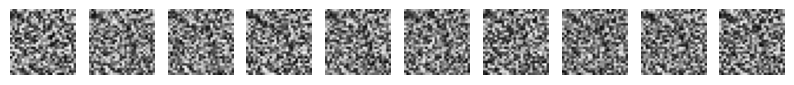

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU
from tensorflow.keras.optimizers import Adam

# -------- Load and preprocess MNIST --------
(X_train, _), (_, _) = mnist.load_data()

# Normalize to [-1, 1]
X_train = (X_train - 127.5) / 127.5
X_train = X_train.reshape(-1, 784)

# -------- Hyperparameters --------
latent_dim = 100

# -------- Generator --------
def build_generator():
    model = Sequential([
        Dense(128, input_dim=latent_dim),
        LeakyReLU(0.2),
        Dense(784, activation='tanh')   # output image
    ])
    return model

# -------- Discriminator --------
def build_discriminator():
    model = Sequential([
        Dense(128, input_dim=784),
        LeakyReLU(0.2),
        Dense(1, activation='sigmoid')
    ])
    return model

# Build models
generator = build_generator()
discriminator = build_discriminator()

# Compile discriminator
discriminator.compile(
    loss='binary_crossentropy',
    optimizer=Adam(0.0002, 0.5),
    metrics=['accuracy']
)

# -------- GAN (Combined Model) --------
discriminator.trainable = False

gan = Sequential([generator, discriminator])
gan.compile(
    loss='binary_crossentropy',
    optimizer=Adam(0.0002, 0.5)
)

# -------- Training --------
epochs = 5000
batch_size = 64

for epoch in range(epochs):

    # ----- Train Discriminator -----
    idx = np.random.randint(0, X_train.shape[0], batch_size)
    real_imgs = X_train[idx]

    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    fake_imgs = generator.predict(noise, verbose=0)

    d_loss_real = discriminator.train_on_batch(real_imgs, np.ones((batch_size, 1)))
    d_loss_fake = discriminator.train_on_batch(fake_imgs, np.zeros((batch_size, 1)))
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    # ----- Train Generator -----
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    g_loss = gan.train_on_batch(noise, np.ones((batch_size, 1)))

    # Print progress
    if epoch % 1000 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss[0]:.4f}, G Loss: {g_loss:.4f}")

# -------- Generate Images --------
noise = np.random.normal(0, 1, (10, latent_dim))
gen_imgs = generator.predict(noise)

# Rescale back to [0,1]
gen_imgs = 0.5 * gen_imgs + 0.5
gen_imgs = gen_imgs.reshape(-1, 28, 28)

# Plot generated images
plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(gen_imgs[i], cmap='gray')
    plt.axis('off')
plt.show()